## Model 2: Hierarchical team model (Stan)

**Idea:** same covariates as Model 1, but team skill combines long-run team quality and season-specific deviations, both measured **in points** (`tau_team`, `tau_season`). One model input = **one team**; output = its **points** distribution.

**Backtest:** train through 2024/25 → predict **points** for each 2025/26 team.

**Forecast:** for a new season, use posterior `team_skill[team]` and simulate a fresh season deviation `tau_season · z` (`z ~ N(0, 1)`); covariates from the last training season. Promoted or unseen teams get `team_skill = 0` plus the same season draw and `beta_promoted` via features.

$$\text{Pts}_{s,t} \sim t_{\nu}\big(\alpha + \text{team\_skill}_{t} + \text{season\_dev}_{s,t} + \gamma^\top x_{s,t},\; \sigma_{\mathrm{pts}}\big)$$

with $x$ = (`sot_diff_pg`, `pts_lag1`, `ppg_last10`, z-scored) plus `is_promoted`, and sum-to-zero constraints for identifiable team and season effects.
Student-$t$ with $\nu=5$ fixed; $\tau_{\mathrm{team}}$ controls persistent team strength and $\tau_{\mathrm{season}}$ controls season-specific deviations.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    compute_table,
    predict_team_points,
    build_predicted_table,
    compare_forecast_to_actual,
    forecast_season_summary,
    forecast_team_errors,
    plot_forecast_team_errors,
    print_forecast_season_summary,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [13]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
FEATURE_SEASON = "2425"  # last training season → covariates for 2526 forecast

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, season_to_idx, feature_stats = (
    prepare_table_stan_hierarchical(tables, TRAIN_SEASONS)
)
stan_data["nu"] = STUDENT_T_NU
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[FEATURE_SEASON]

print(f"Training rows (team-seasons): {stan_data['N']}")
print(f"Stan keys: {sorted(stan_data.keys())}")
print(f"Teams in training: {stan_data['T']}")
print(f"Test season {TEST_SEASON}: {len(test_teams)} teams")
print(tables.groupby("season")["Pts"].mean().tail(3))
print("\nFeature ranges (raw, training seasons):")
print(tables[["sot_diff_pg", "pts_lag1", "ppg_last10"]].describe().round(2))
print(f"\nForecast uses season {FEATURE_SEASON} (Stan index {last_season_idx})")

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Promoted / new teams (is_promoted=1, covariates=training mean):", new_in_test)


Training rows (team-seasons): 320
Stan keys: ['N', 'S', 'T', 'is_promoted', 'nu', 'ppg_last10', 'pts', 'pts_lag1', 'season', 'sot_diff_pg', 'team']
Teams in training: 42
Test season 2526: 20 teams
season
2223    52.65
2324    52.90
2425    52.35
Name: Pts, dtype: float64

Feature ranges (raw, training seasons):
       sot_diff_pg  pts_lag1  ppg_last10
count       320.00    320.00      320.00
mean          0.30     45.02        1.21
std           1.70     26.80        0.78
min          -3.76      0.00        0.00
25%          -0.74     38.00        0.70
50%           0.00     47.00        1.30
75%           1.14     63.25        1.80
max           6.03    100.00        3.00

Forecast uses season 2425 (Stan index 16)


### Prior selection (Model 2)

| Parameter | Prior | Expert rationale |
|-----------|-------|------------------|
| `intercept` | $\mathcal{N}(52, 10)$ | Baseline around the average points total in a 20-team Premier League season. |
| `beta_sot`, `beta_form` | $\mathcal{N}(0, 8)$ | Process/form effects on z-scored inputs; broad points-scale effects are allowed. |
| `beta_lag` | $\mathcal{N}(0, 0.5)$ | Conservative lagged-points effect because persistent quality is captured by `team_skill`. |
| `beta_promoted` | $\mathcal{N}(-10, 5)$ | Promoted-team penalty; allows large penalty, small penalty, or near-zero effect if data support it. |
| `log_sigma_pts` | $\mathcal{N}(\log 4.5, 0.12)$ | After team skill + covariates, unpredictable season noise is expected to be about 4-6 Student-$t$ scale points. |
| `log_tau_team` | $\mathcal{N}(\log 7, 0.20)$ | Persistent residual team-strength spread beyond process metrics. |
| `log_tau_season` | $\mathcal{N}(\log 2.25, 0.18)$ | Small season-specific deviations around long-run team strength. |
| `team_skill_z`, `season_dev_z` | sum-to-zero standard Normal vectors | Non-centered geometry with interpretable points-scale multipliers. |

The hierarchy is:

$\text{skill_obs}_{n} = \text{team_skill}_{team[n]} + \tau_{season}\,\text{season_dev_z}_{season[n],obs\_pos[n]}$.

`team_skill` captures long-run residual quality, while `season_dev` captures one-season over/under-performance. Priors were chosen before model fitting from football scale: residual team differences of several points are plausible, but season-specific deviations should be smaller than persistent team quality.


### Prior predictive checks

The checks below separate two questions required by the rubric:

- **Parameter priors:** do `sigma_pts`, `tau_team`, `tau_season`, `beta_promoted`, and the other coefficients imply football-scale values?
- **Measurement priors:** after combining parameters with lag-safe covariates, do simulated team-season point totals look broadly plausible before conditioning on observed points?


,0.05,0.50,0.95
intercept,35.488292,51.988122,68.339934
beta_sot,-13.502537,-0.090220,13.067169
beta_lag,-0.830642,-0.001901,0.830535
beta_form,-13.129701,0.115849,13.201099
beta_promoted,-18.307420,-10.034826,-1.705441
sigma_pts,3.713142,4.512161,5.447889
tau_team,5.045715,6.997589,9.709438
tau_season,1.683996,2.245164,2.992160
team_skill_range,19.827318,30.059910,44.936105
season_dev_range,10.066623,13.815898,19.141841


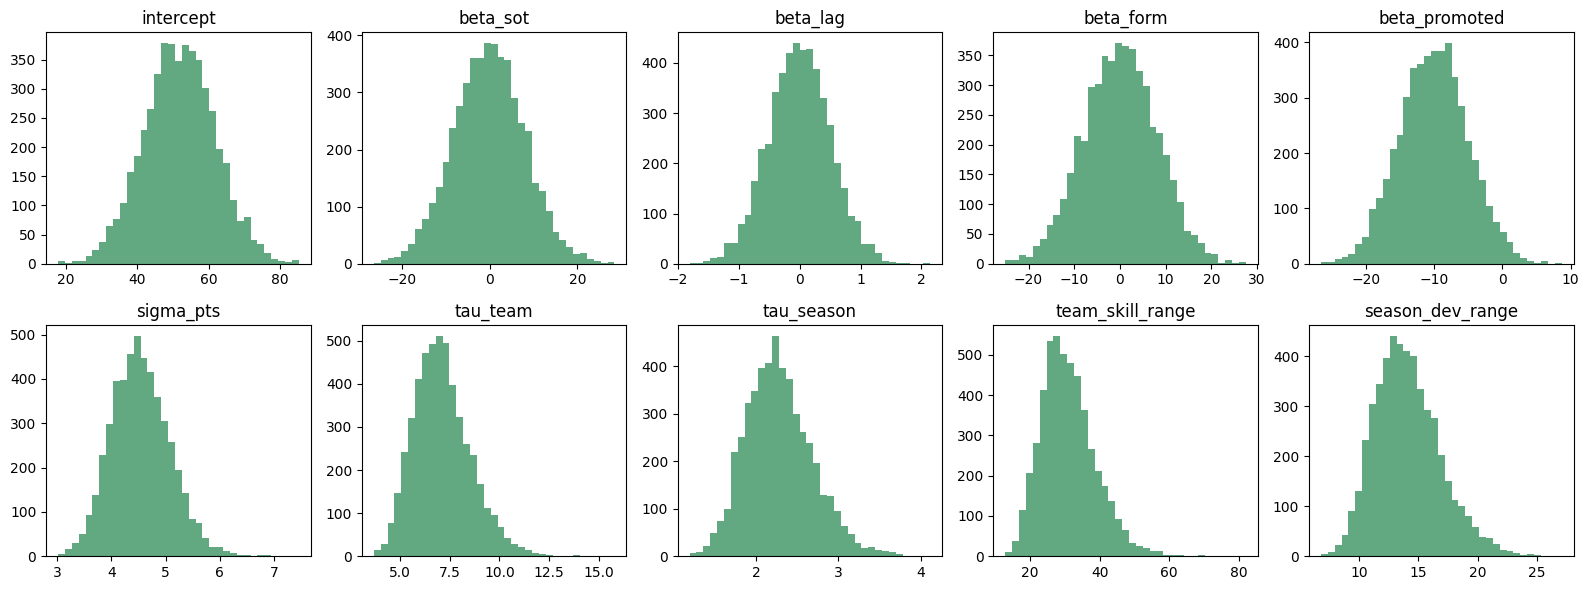

Prior points mean: 50.7; observed mean: 52.4
Prior central 90% interval: 20.4 to 79.8
Observed range: 12 to 100


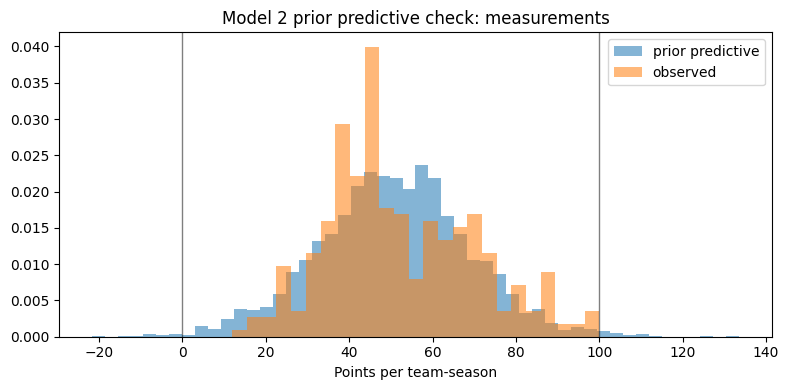

In [14]:
rng = np.random.default_rng(43)
n_prior = 5000
T = stan_data["T"]
S = stan_data["S"]
nu_prior = STUDENT_T_NU

def rtrunc_normal(mean, sd, lower=-np.inf, upper=np.inf, size=1):
    out = np.empty(size)
    filled = 0
    while filled < size:
        draws = rng.normal(mean, sd, size - filled)
        draws = draws[(draws >= lower) & (draws <= upper)]
        take = min(len(draws), size - filled)
        if take:
            out[filled:filled + take] = draws[:take]
            filled += take
    return out

intercept_p = rng.normal(52, 10, n_prior)
beta_sot_p = rng.normal(0, 8, n_prior)
beta_lag_p = rng.normal(0, 0.5, n_prior)
beta_form_p = rng.normal(0, 8, n_prior)
beta_promoted_p = rng.normal(-10, 5, n_prior)

sigma_p = np.exp(rtrunc_normal(np.log(4.5), 0.12, lower=np.log(0.5), upper=np.log(20), size=n_prior))
tau_team_p = np.exp(rtrunc_normal(np.log(7), 0.20, lower=np.log(1), upper=np.log(25), size=n_prior))
tau_season_p = np.exp(rtrunc_normal(np.log(2.25), 0.18, lower=np.log(0.25), upper=np.log(15), size=n_prior))

team_skill_z = rng.normal(0, 1, (n_prior, T))
team_skill_z -= team_skill_z.mean(axis=1, keepdims=True)
team_skill = tau_team_p[:, None] * team_skill_z

season_dev_z = rng.normal(0, 1, (n_prior, S, T))
season_dev_z -= season_dev_z.mean(axis=2, keepdims=True)
season_dev = tau_season_p[:, None, None] * season_dev_z

prior_params = pd.DataFrame({
    "intercept": intercept_p,
    "beta_sot": beta_sot_p,
    "beta_lag": beta_lag_p,
    "beta_form": beta_form_p,
    "beta_promoted": beta_promoted_p,
    "sigma_pts": sigma_p,
    "tau_team": tau_team_p,
    "tau_season": tau_season_p,
    "team_skill_range": team_skill.max(axis=1) - team_skill.min(axis=1),
    "season_dev_range": season_dev.reshape(n_prior, -1).max(axis=1) - season_dev.reshape(n_prior, -1).min(axis=1),
})
display(prior_params.quantile([0.05, 0.5, 0.95]).T)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.ravel(), prior_params.columns):
    ax.hist(prior_params[col], bins=35, color="seagreen", alpha=0.75)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Measurement prior predictive: sample actual design rows, but draw parameters from prior.
idx = rng.integers(0, stan_data["N"], size=3000)
draw = rng.integers(0, n_prior, size=3000)
teams = np.asarray(stan_data["team"])[idx] - 1
seasons = np.asarray(stan_data["season"])[idx] - 1

skill_obs_prior = team_skill[draw, teams] + season_dev[draw, seasons, teams]
mu_prior = (
    intercept_p[draw]
    + skill_obs_prior
    + beta_sot_p[draw] * np.asarray(stan_data["sot_diff_pg"])[idx]
    + beta_lag_p[draw] * np.asarray(stan_data["pts_lag1"])[idx]
    + beta_form_p[draw] * np.asarray(stan_data["ppg_last10"])[idx]
    + beta_promoted_p[draw] * np.asarray(stan_data["is_promoted"])[idx]
)
pts_prior = mu_prior + sigma_p[draw] * rng.standard_t(nu_prior, size=len(draw))

print(f"Prior points mean: {pts_prior.mean():.1f}; observed mean: {np.mean(stan_data['pts']):.1f}")
print(f"Prior central 90% interval: {np.quantile(pts_prior, 0.05):.1f} to {np.quantile(pts_prior, 0.95):.1f}")
print(f"Observed range: {np.min(stan_data['pts']):.0f} to {np.max(stan_data['pts']):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(pts_prior, bins=50, density=True, alpha=0.55, label="prior predictive")
plt.hist(stan_data["pts"], bins=25, density=True, alpha=0.55, label="observed")
plt.axvline(0, color="black", lw=1, alpha=0.5)
plt.axvline(100, color="black", lw=1, alpha=0.5)
plt.xlabel("Points per team-season")
plt.title("Model 2 prior predictive check: measurements")
plt.legend()
plt.tight_layout()
plt.show()


**Prior predictive interpretation (Model 2):** `tau_team` should dominate `tau_season`, because persistent club quality should vary more than one-year noise around that quality. `sigma_pts` should be smaller than raw table-point SD because the model already explains points with team quality and covariates. The measurement prior can be wider than observed data, but its central mass should describe plausible league seasons rather than impossible point totals.

In [15]:
model = CmdStanModel(stan_file="stan/team_hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


09:12:42 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:13:07 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics

Check divergences (`fit.diagnose()` above), $\hat{R}$, and ESS.
Target: $\hat{R} \leq 1.01$, ESS bulk $\gtrsim 400$ per parameter.


                      Mean      MCSE     StdDev        MAD           5%  \
intercept        50.053400  0.017688   0.932023   0.937003    48.517200   
beta_sot          6.151600  0.013958   0.899118   0.888441     4.672970   
beta_lag         -0.014495  0.005095   0.489755   0.494748    -0.826738   
beta_form         1.097750  0.011996   0.937885   0.945848    -0.429443   
beta_promoted    -8.830450  0.031444   2.195550   2.188240   -12.414300   
sigma_pts         7.415840  0.008206   0.427120   0.413497     6.708460   
tau_team          7.455750  0.019014   0.988091   0.954898     5.963590   
tau_season        2.765090  0.016083   0.627715   0.580075     1.892620   
lp__          -1238.470000  0.509403  20.897800  20.934300 -1272.820000   

                      50%          95%  ESS_bulk  ESS_tail    R_hat  
intercept        50.04090    51.577900   2801.25   4145.48  1.00366  
beta_sot          6.12561     7.652380   4159.62   3663.24  1.00110  
beta_lag         -0.01121     0.796049 

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
intercept,50.053,0.932,48.232,51.712,2801.0,4145.0,1.0
beta_sot,6.152,0.899,4.494,7.866,4160.0,3663.0,1.0
beta_lag,-0.014,0.490,-0.887,0.945,9279.0,4449.0,1.0
beta_form,1.098,0.938,-0.524,2.986,6051.0,4755.0,1.0
beta_promoted,-8.830,2.196,-12.836,-4.569,4873.0,4533.0,1.0
sigma_pts,7.416,0.427,6.651,8.265,2818.0,2211.0,1.0
tau_team,7.456,0.988,5.688,9.352,2713.0,4370.0,1.0
tau_season,2.765,0.628,1.675,3.941,1839.0,1998.0,1.0


Parameters with R-hat > 1.01: 0
Parameters with ESS_bulk < 400: 0


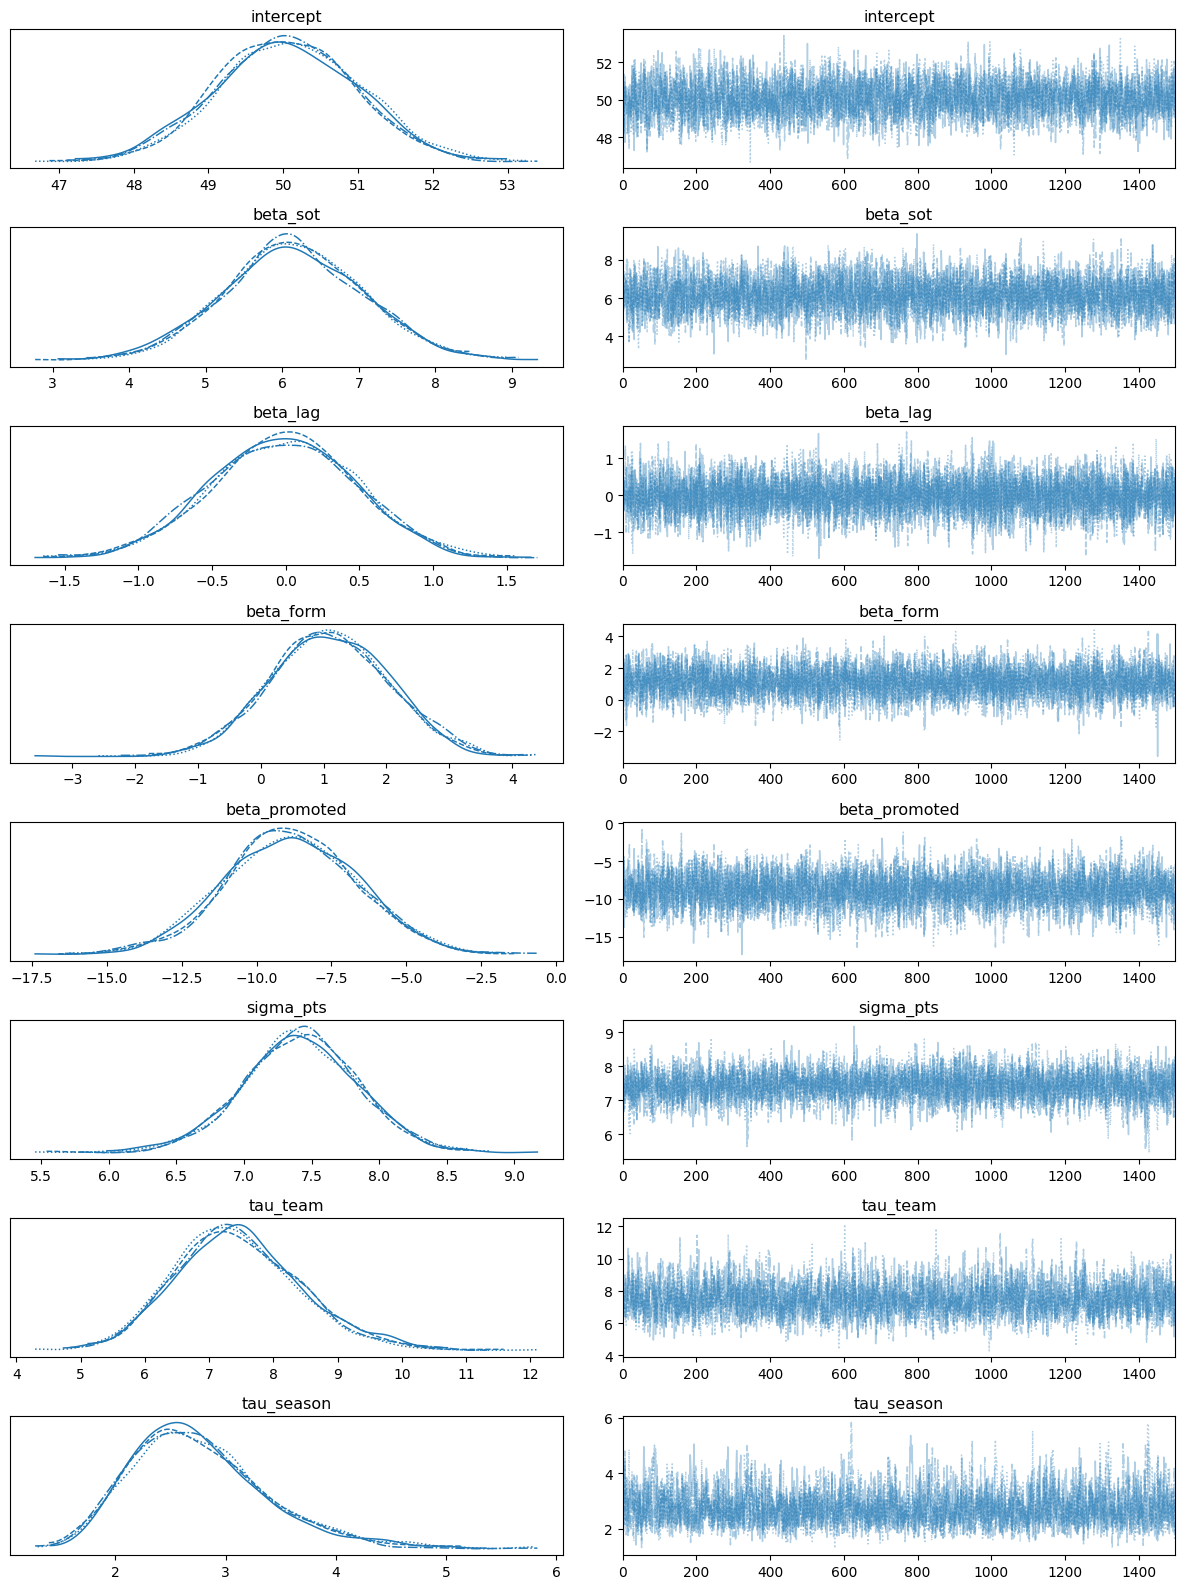

In [16]:
param_vars = [
    "intercept", "beta_sot", "beta_lag", "beta_form", "beta_promoted",
    "sigma_pts", "tau_team", "tau_season",
]
print(fit.summary().loc[param_vars + ["lp__"]])

idata = az.from_cmdstanpy(fit)
diag = az.summary(idata, var_names=param_vars)
cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
display(diag[cols])

bad_rhat = diag[diag["r_hat"] > 1.01]
low_ess = diag[diag["ess_bulk"] < 400]
print(f"Parameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat):
    display(bad_rhat[cols])
print(f"Parameters with ESS_bulk < 400: {len(low_ess)}")
if len(low_ess):
    display(low_ess[cols])

az.plot_trace(idata, var_names=param_vars, compact=True)
plt.tight_layout()
plt.show()


### Interpreting $\sigma_{\mathrm{pts}}$, $\tau_{\mathrm{team}}$, $\tau_{\mathrm{season}}$, and skills

| Parameter | Order of magnitude | Meaning |
|-----------|-------------------|---------|
| `tau_team` | ~6-10 pts | Persistent residual team quality beyond process metrics. |
| `tau_season` | ~1.5-3 pts | Season-specific deviation around long-run team quality. |
| `team_skill[t]` | roughly +/-15-25 pts range across clubs | Long-run residual club strength on the points scale. |
| `skill[s,t]` | `team_skill + season_dev` | Combined skill used for historical team-season rows. |
| `sigma_pts` | ~4-7 | Student-$t$ scale for leftover noise; approximate SD is $\sigma\sqrt{\nu/(\nu-2)}$. |

**Why $\sigma_{\mathrm{pts}} \ll 17$?** Around 17 points is close to the raw spread of final table points. In this model, team quality, promoted status, and lag-safe covariates explain much of that spread. `sigma_pts` is only the remaining unpredictable season noise.


In [17]:
s_idx = last_season_idx - 1
skill_last = fit.stan_variable("skill")[:, s_idx, :].mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

pd.DataFrame({
    "team": [idx_to_team[j+1] for j in range(len(skill_last))],
    "skill": skill_last,
}).sort_values("skill", ascending=False).head(10)


,team,skill
22,Man City,17.501848
0,Arsenal,12.945137
20,Liverpool,12.761485
23,Man United,12.717686
11,Chelsea,11.785162
36,Tottenham,9.451537
7,Brentford,4.861696
1,Aston Villa,3.646226
25,Newcastle,3.330376
33,Stoke,3.057934


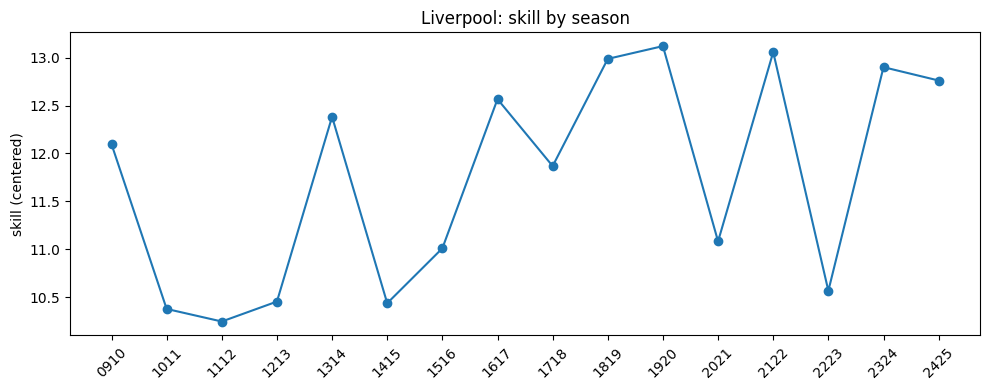

In [18]:
example_team = "Liverpool"
if example_team in team_to_idx:
    j = team_to_idx[example_team] - 1
    skill_ts = fit.stan_variable("skill")[:, :, j].mean(axis=0)
    seasons = list(season_to_idx.keys())
    plt.figure(figsize=(10, 4))
    plt.plot(seasons, skill_ts, marker="o")
    plt.xticks(rotation=45)
    plt.ylabel("skill (centered)")
    plt.title(f"{example_team}: skill by season")
    plt.tight_layout()
    plt.show()


### Posterior predictive check (PPC)

Simulate **replicated team-season points** from the posterior (Student-$t$ likelihood).
Compare the distribution and simple test statistics (mean, SD, min, max) to observed training points.
$p \approx 0.5$ suggests good calibration; values near 0 or 1 flag misfit.


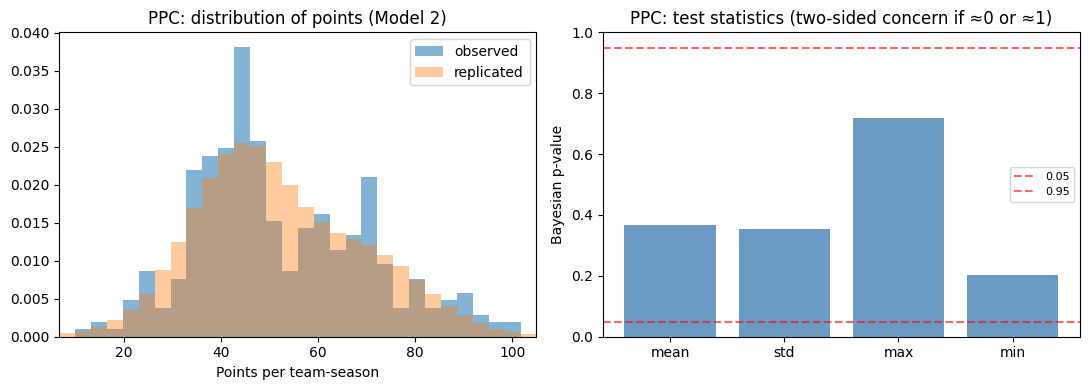

PPC x-axis shown: 6.7 to 105.0 points
Replicated draws outside shown range: 0.45%
  mean: p = 0.366
  std: p = 0.355
  max: p = 0.720
  min: p = 0.204


In [19]:
from helping_functions import ppc_table_replicates

y_obs = stan_data["pts"]
y_rep = ppc_table_replicates(fit, stan_data, model="hierarchical")
y_rep_flat = y_rep.reshape(-1)

# Focus the PPC plot on the observed range and the central model mass.
# Student-t tails can create rare extreme draws that otherwise stretch the x-axis.
q_low, q_high = np.quantile(y_rep_flat, [0.005, 0.995])
plot_low = max(0, min(y_obs.min(), q_low) - 5)
plot_high = min(110, max(y_obs.max(), q_high) + 5)
bins = np.linspace(plot_low, plot_high, 31)
outside = np.mean((y_rep_flat < plot_low) | (y_rep_flat > plot_high))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_obs, bins=bins, density=True, alpha=0.55, label="observed")
axes[0].hist(y_rep_flat, bins=bins, density=True, alpha=0.4, label="replicated")
axes[0].set_xlim(plot_low, plot_high)
axes[0].set_xlabel("Points per team-season")
axes[0].set_title("PPC: distribution of points (Model 2)")
axes[0].legend()

stats = {"mean": np.mean, "std": np.std, "max": np.max, "min": np.min}
pvals = {}
for name, fn in stats.items():
    obs_val = fn(y_obs)
    rep_vals = fn(y_rep, axis=1)
    pvals[name] = float((rep_vals >= obs_val).mean())

axes[1].bar(pvals.keys(), pvals.values(), color="steelblue", alpha=0.8)
axes[1].axhline(0.05, color="red", ls="--", alpha=0.6, label="0.05")
axes[1].axhline(0.95, color="red", ls="--", alpha=0.6, label="0.95")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Bayesian p-value")
axes[1].set_title("PPC: test statistics (two-sided concern if ≈0 or ≈1)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"PPC x-axis shown: {plot_low:.1f} to {plot_high:.1f} points")
print(f"Replicated draws outside shown range: {100 * outside:.2f}%")
for name, p in pvals.items():
    print(f"  {name}: p = {p:.3f}")


**PPC interpretation (Model 2):** same logic as Model 1. If replicated points are too narrow or too wide relative to observed points, the likely culprits are `sigma_pts`, `tau_team`, or `tau_season`. If promoted teams are systematically overpredicted, inspect `beta_promoted`. Good PPC behavior means the hierarchical decomposition still reproduces the empirical distribution of table points, not only the parameter diagnostics.

### Backtest 2025/26 — per-team points

For each test team we call `predict_team_points` and compare predicted vs actual **points**. Position comparison uses ranking as a derived summary; assembling a full table from 20 predictions is shown in `05_backtest_models_comparison`.

**Forecast skill (Model 2):** posterior `team_skill[team]` plus a **new** draw `tau_season · z`, `z ~ N(0, 1)` for season 2526 (not the mean of historical `skill[s, team]`). Covariates come from 2425 via `build_forecast_features`.


In [20]:
forecast_features = build_forecast_features(
    matches, FEATURE_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

# Per-team posterior predictive points
single_rows = []
for j, team in enumerate(test_teams):
    pred = predict_team_points(
        fit,
        team,
        team_to_idx,
        model="hierarchical",
        team_features=forecast_features[team],
        n_sims=500,
        seed=42 + j,
    )
    single_rows.append(pred)
single_df = pd.DataFrame(single_rows)
display(single_df[["team", "pts_median", "pts_mean", "pts_q05", "pts_q95"]].sort_values("pts_median", ascending=False))

pred_table = build_predicted_table(
    fit,
    test_teams,
    team_to_idx,
    model="hierarchical",
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)

comparison = compare_forecast_to_actual(pred_table, matches, TEST_SEASON)
season_summary = forecast_season_summary(comparison)
team_errors = forecast_team_errors(comparison)

print_forecast_season_summary(season_summary, season=TEST_SEASON)

display(team_errors)
season_summary


,team,pts_median,pts_mean,pts_q05,pts_q95
12,Man City,77.428530,77.630485,62.188328,92.363337
11,Liverpool,70.045653,70.039125,54.984042,85.782957
0,Arsenal,69.717309,68.667681,50.069490,83.706578
6,Chelsea,67.989445,67.705605,50.595835,84.028862
13,Man United,64.836677,64.706917,47.691480,80.279699
17,Tottenham,58.601563,58.619193,43.240197,72.365301
1,Aston Villa,54.441311,54.513885,38.016796,72.438813
14,Newcastle,53.541375,53.485551,37.838717,69.706131
4,Brighton,53.297349,53.466901,38.584602,69.727446
7,Crystal Palace,51.980733,52.096867,36.438701,67.263789


Season 2526 — Point forecast quality
  Sum |point error| over all teams:  181 pts
  Mean |point error| per team:        9.03 pts  (181 / 20)
  Mean signed point error (bias):     +2.09 pts
  Mean predicted / actual points:     53.9 / 51.8
  Sum |position error|:               76 places
  Mean |position error| per team:     3.80 places  (76 / 20)


,team,pts_median,pts_actual,pts_error,pts_abs_error,pos_median,pos_actual,pos_error,pos_abs_error
15,Wolves,47.021875,20,27.021875,27.021875,16,20,-4,4
5,Tottenham,58.601563,41,17.601563,17.601563,6,17,-11,11
3,Chelsea,67.989445,52,15.989445,15.989445,4,10,-6,6
17,Sunderland,38.121334,54,-15.878666,15.878666,18,7,11,11
19,Burnley,37.421169,22,15.421169,15.421169,20,19,1,1
2,Arsenal,69.717309,85,-15.282691,15.282691,3,1,2,2
6,Aston Villa,54.441311,65,-10.558689,10.558689,7,4,3,3
1,Liverpool,70.045653,60,10.045653,10.045653,2,5,-3,3
18,Leeds,37.626286,47,-9.373714,9.373714,19,14,5,5
16,West Ham,46.086708,39,7.086708,7.086708,17,18,-1,1


n_teams               20.000000
pts_pred_mean         53.890117
pts_actual_mean       51.800000
pts_mae                9.029256
pts_abs_error_sum    180.585115
pts_bias               2.090117
pos_mae                3.800000
pos_abs_error_sum     76.000000
pos_bias               0.000000
dtype: float64

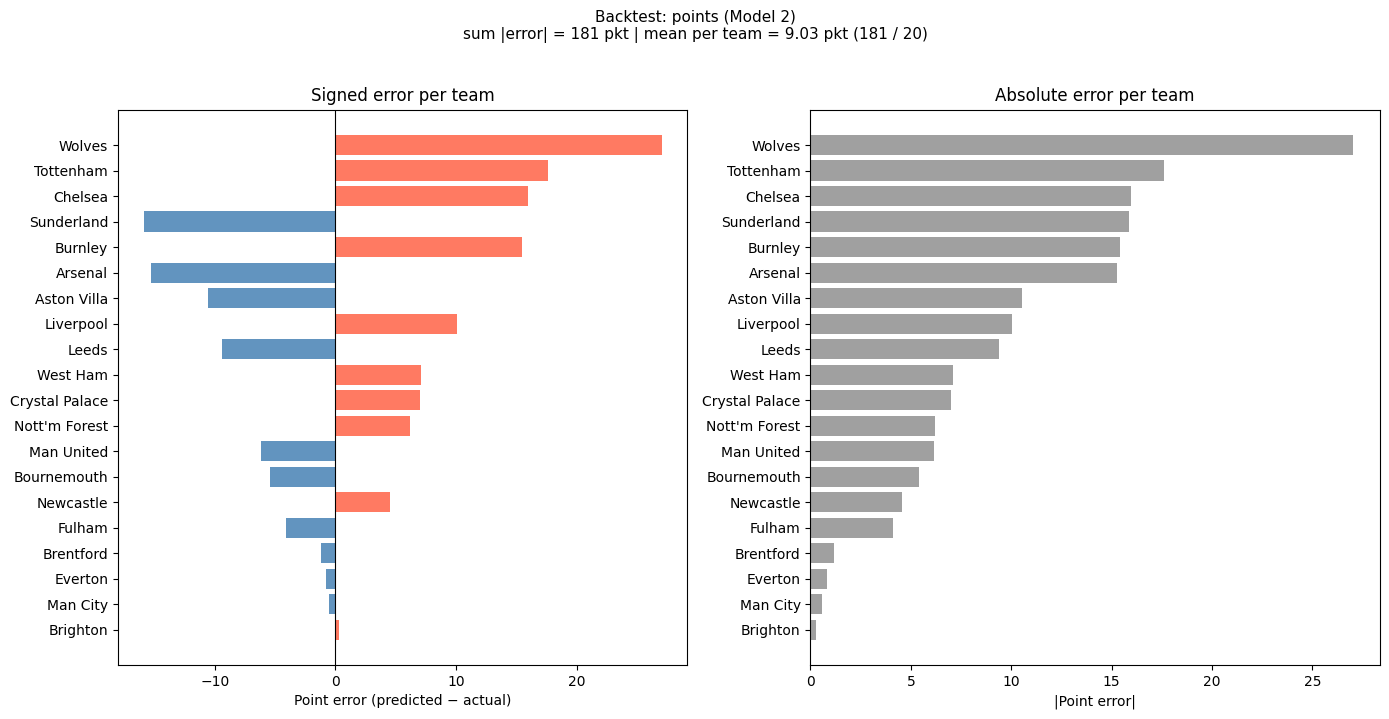

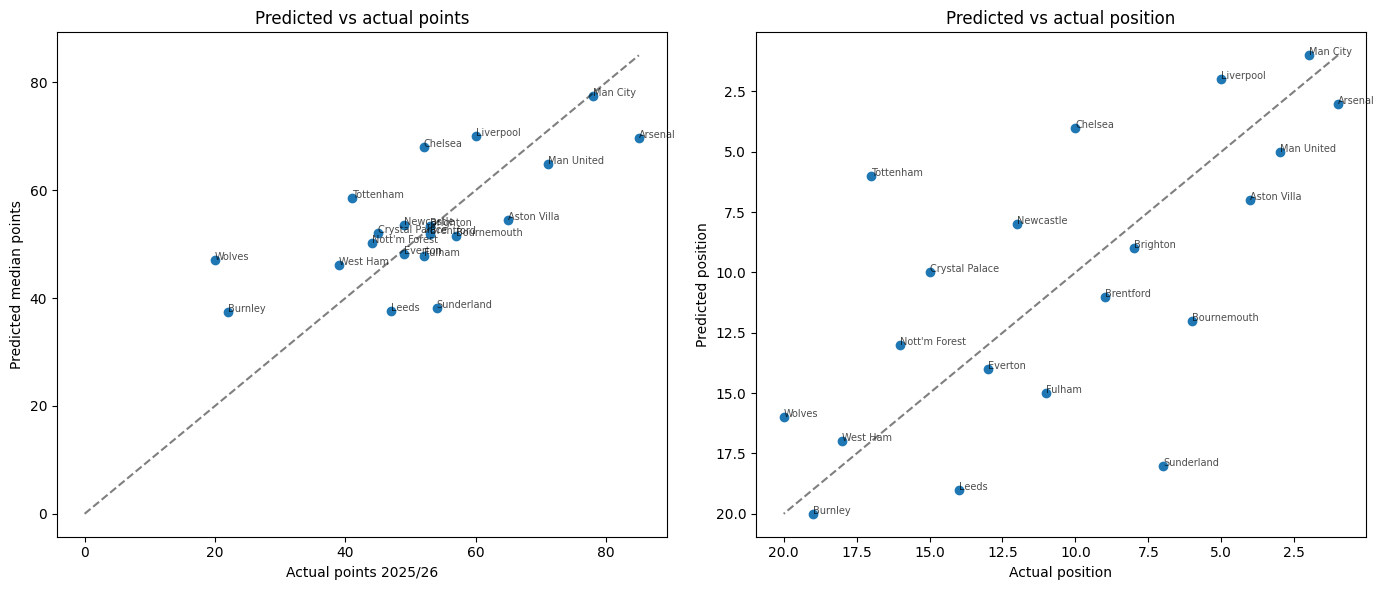

In [21]:
plot_forecast_team_errors(comparison, season=TEST_SEASON, title="Backtest: points (Model 2)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(comparison["pts_actual"], comparison["pts_median"])
for _, r in comparison.iterrows():
    axes[0].annotate(r["team"], (r["pts_actual"], r["pts_median"]), fontsize=7, alpha=0.7)
mx = max(comparison["pts_actual"].max(), comparison["pts_median"].max())
axes[0].plot([0, mx], [0, mx], "k--", alpha=0.5)
axes[0].set_xlabel("Actual points 2025/26")
axes[0].set_ylabel("Predicted median points")
axes[0].set_title("Predicted vs actual points")

axes[1].scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    axes[1].annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
axes[1].plot([1, 20], [1, 20], "k--", alpha=0.5)
axes[1].set_xlabel("Actual position")
axes[1].set_ylabel("Predicted position")
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_title("Predicted vs actual position")
plt.tight_layout()
plt.show()


### WAIC / LOO

This is a single-model diagnostic version of the information criteria. The final comparison between Model 1 and Model 2 is done in `04_forecast_2627_comparison` on the same team-season rows.

For PSIS-LOO, check `pareto_k`: values $\leq 0.7$ are reliable; values above 0.7 indicate influential team-seasons. For WAIC, warnings about high posterior variance of log predictive density mean WAIC may be less stable, so PSIS-LOO and the backtest (`05_backtest_models_comparison`, `04_forecast_2627_comparison`) should receive more weight.

In [22]:
idata = az.from_cmdstanpy(fit)
print(az.waic(idata))
loo = az.loo(idata, pointwise=True)
print(loo)

k = loo.pareto_k.values
n_good = int((k <= 0.7).sum())
n_bad = int(((k > 0.7) & (k <= 1)).sum())
n_very_bad = int((k > 1).sum())
print(f"\nPareto k: good (≤0.7) {n_good}/{len(k)} ({100 * n_good / len(k):.1f}%)")
print(f"           bad (0.7–1] {n_bad}, very bad (>1) {n_very_bad}")


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1224.67    15.71
p_waic       73.16        -

There has been a warning during the calculation. Please check the results.
Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1225.61    15.68
p_loo       74.10        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      320  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Pareto k: good (≤0.7) 320/320 (100.0%)
           bad (0.7–1] 0, very bad (>1) 0
